# Preprocesamiento Bank Marketing

Notebook maestro del proyecto. El flujo parte con la separacion de Train/Test antes de cualquier transformacion aprendida.

## Objetivo

Preparar el dataset `bank-additional-full.csv` para analisis, limpieza, preprocesamiento y futura modelacion, evitando fuga de informacion.

## Regla metodologica

1. Cargar el dataset original.
2. Separar `X` e `y`.
3. Ejecutar `train_test_split(..., stratify=y, random_state=42)`.
4. Reservar `X_test` y `y_test` para la validacion final.
5. Hacer limpieza, EDA y transformaciones aprendidas solo con `Train`.

In [46]:
import pandas as pd
from pathlib import Path
import sys

NOTEBOOK_CWD = Path.cwd().resolve()
for base in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents]:
    for candidate in (base, base / "bank_marketing" / "notebooks"):
        if (candidate / "preprocessing.py").exists():
            sys.path.insert(0, str(candidate))
            break
    else:
        continue
    break
else:
    raise ModuleNotFoundError("No se encontro preprocessing.py")
from preprocessing import load_data, split_data

DATA_PATH = '../data/raw/bank-additional-full.csv'
TARGET = 'y'
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

df = load_data(DATA_PATH)
X_train, X_test, y_train, y_test = split_data(df, TARGET)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train distribution:')
print(y_train.value_counts(normalize=True).round(4))
print('y_test distribution:')
print(y_test.value_counts(normalize=True).round(4))

X_train.to_csv(processed_dir / 'X_train_clean.csv', index=False)
y_train.to_csv(processed_dir / 'y_train_clean.csv', index=False)
X_test.to_csv(processed_dir / 'X_test_clean.csv', index=False)
y_test.to_csv(processed_dir / 'y_test_clean.csv', index=False)

print('Archivos generados en', processed_dir)


X_train: (32950, 20)
X_test: (8238, 20)
y_train distribution:
y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64
y_test distribution:
y
no     0.8874
yes    0.1126
Name: proportion, dtype: float64
Archivos generados en ../data/processed


### Split Train/Test

,subset,yes,no
0,train,0.1127,0.8873
1,test,0.1126,0.8874


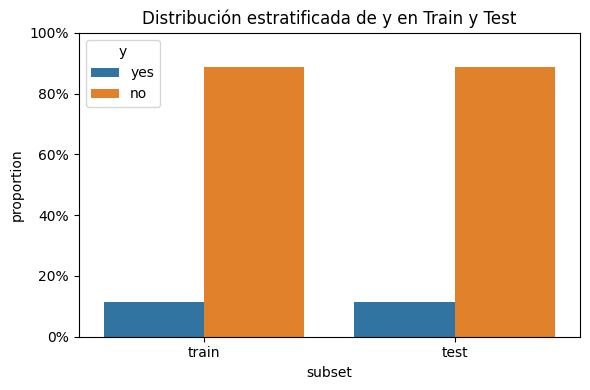

In [47]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import seaborn as sns

split_df = pd.DataFrame({
    'subset': ['train', 'test'],
    'yes': [(y_train == 'yes').mean(), (y_test == 'yes').mean()],
    'no': [(y_train == 'no').mean(), (y_test == 'no').mean()]
})

display(split_df.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
split_df_melt = split_df.melt(id_vars='subset', value_vars=['yes', 'no'], var_name='y', value_name='proportion')
sns.barplot(data=split_df_melt, x='subset', y='proportion', hue='y', ax=ax)
ax.set_title('Distribución estratificada de y en Train y Test')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.tight_layout()
plt.show()


## EDA sobre Train limpio

A partir de este punto el analisis descriptivo se hace sobre `X_train_clean` y `y_train_clean`, sin tocar `Test`.

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

X_train_clean = pd.read_csv('../data/processed/X_train_clean.csv').replace('', pd.NA)
y_train_clean = pd.read_csv('../data/processed/y_train_clean.csv')
train_df = X_train_clean.copy()
train_df['y'] = y_train_clean['y']

print(train_df.shape)
display(train_df.head())
display(train_df.describe(include='all').T)
print(train_df['y'].value_counts())
print(train_df.isna().sum().sort_values(ascending=False).head(10))

(32950, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,...,4,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
1,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,...,2,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8,no
2,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,...,1,999,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6,yes
3,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,...,2,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2,no


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,32950.0,NaN,NaN,NaN,40.014112,10.403636,17.0,32.0,38.0,47.0,98.0
job,32950,12,admin.,8314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,32950,4,married,19953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,32950,8,university.degree,9736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,32950,3,no,26007,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,32950,3,yes,17254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,32950,3,no,27131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,32950,2,cellular,20908,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,32950,10,may,11011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,32950,5,thu,6857,NaN,NaN,NaN,NaN,NaN,NaN,NaN


y
no     29238
yes     3712
Name: count, dtype: int64
age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
dtype: int64


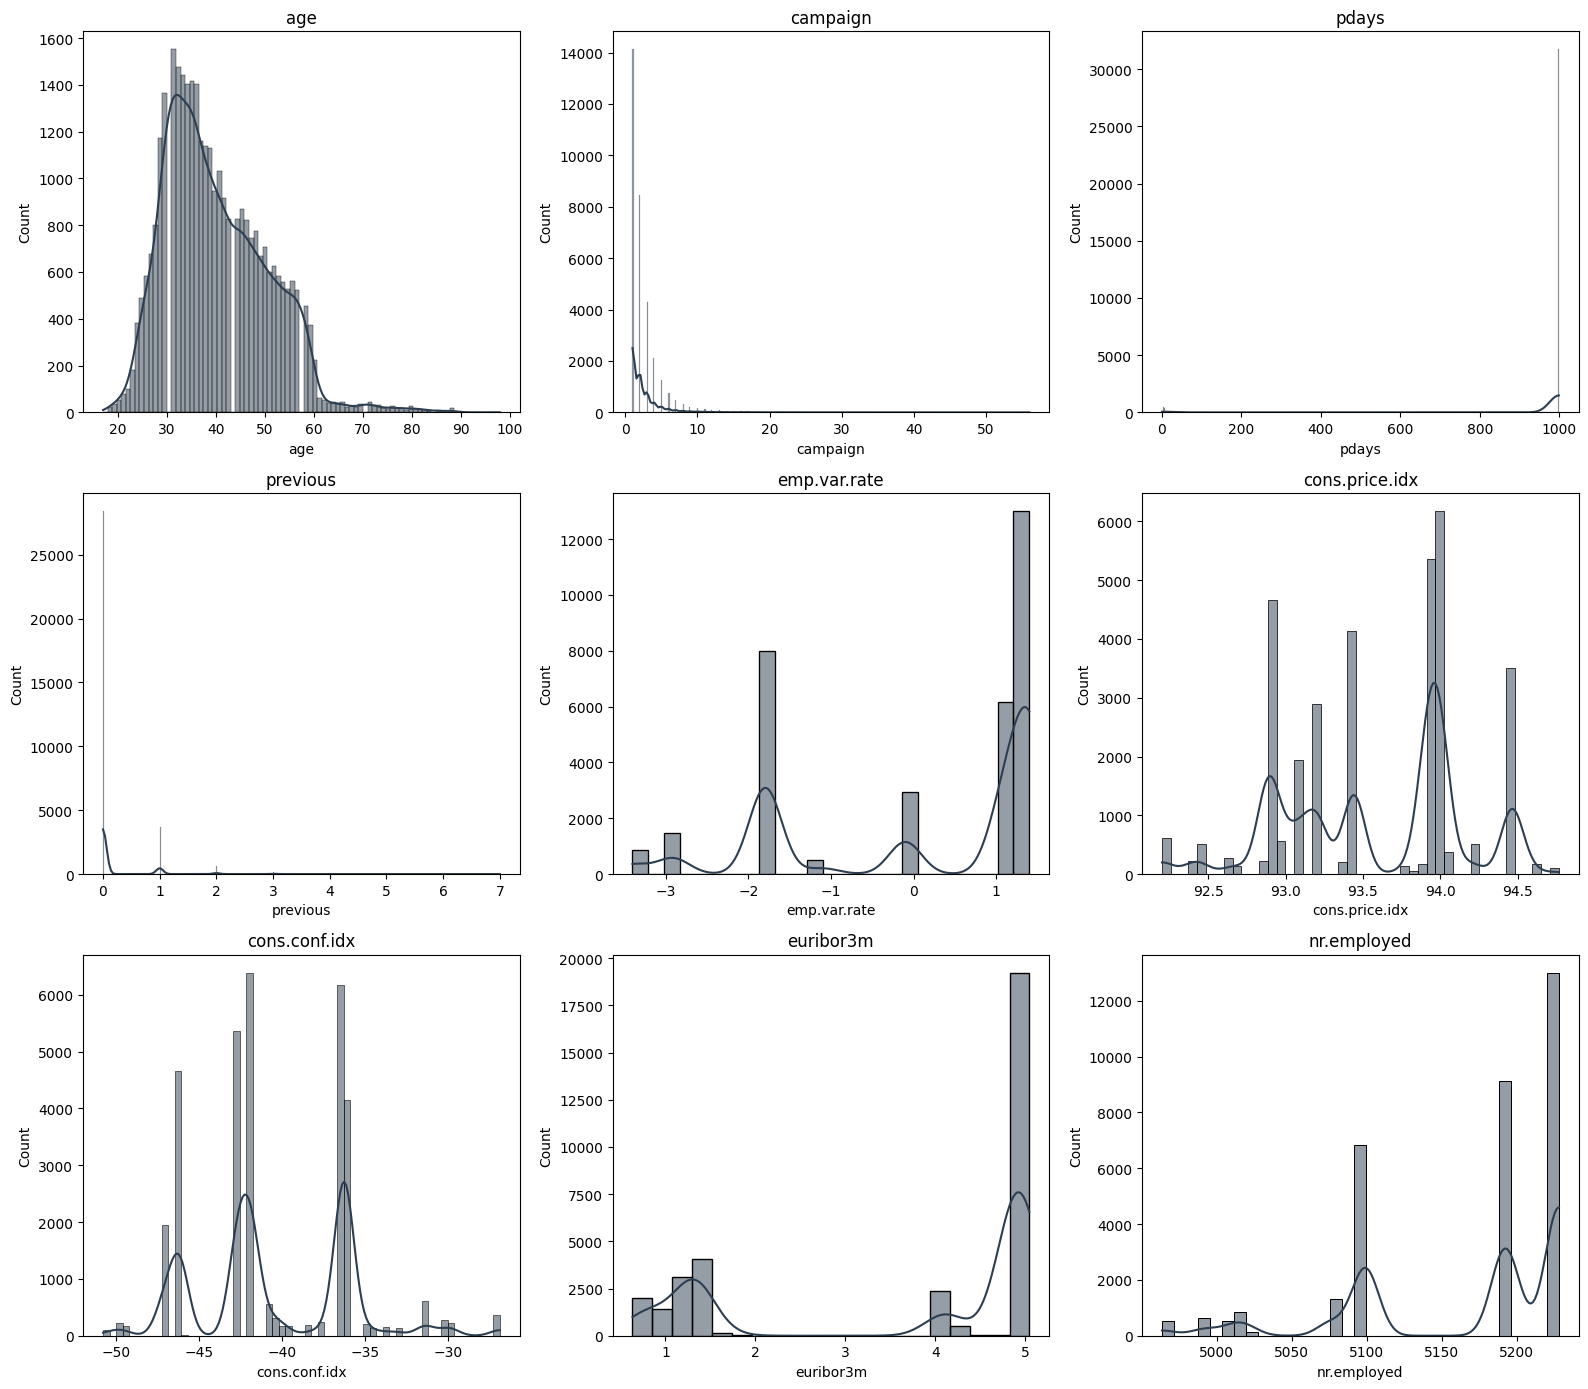

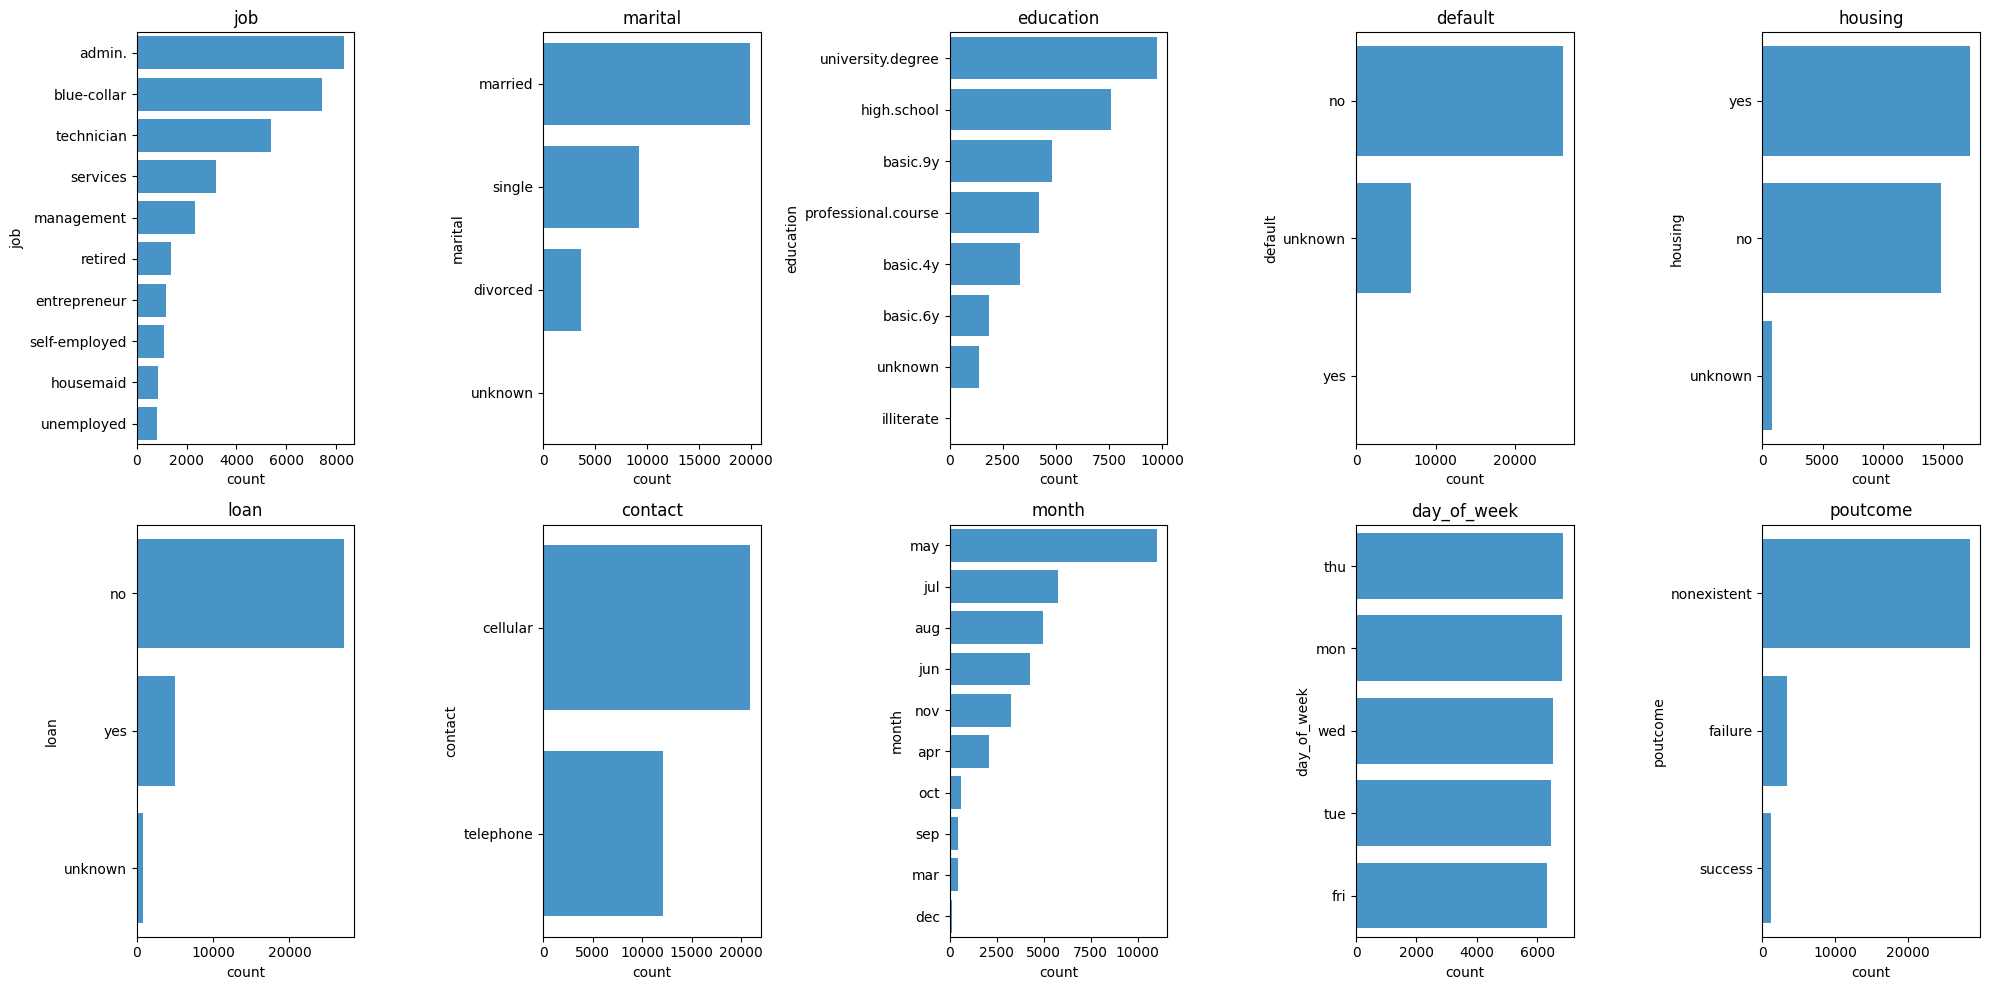

In [49]:
numeric_cols = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

categorical_cols = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'day_of_week', 'poutcome'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=train_df, x=col, kde=True, ax=ax, color='#2c3e50')
    ax.set_title(col)
plt.tight_layout()

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.ravel()
for ax, col in zip(axes, categorical_cols):
    order = train_df[col].value_counts().index[:10]
    sns.countplot(data=train_df, y=col, order=order, ax=ax, color='#3498db')
    ax.set_title(col)
plt.tight_layout()


## EDA bivariado con la variable objetivo

El objetivo aqui es comparar tasas de conversion y comportamiento numerico entre `yes` y `no`, usando solamente `Train`.

y,job,yes,no,conversion_rate
0,student,0.305204,0.694796,30.520394
1,retired,0.254758,0.745242,25.475842
2,unemployed,0.145363,0.854637,14.536341
3,admin.,0.128699,0.871301,12.869858
4,unknown,0.124528,0.875472,12.452830
5,management,0.114712,0.885288,11.471215
6,technician,0.108333,0.891667,10.833333
7,self-employed,0.108280,0.891720,10.828025
8,housemaid,0.100585,0.899415,10.058480
9,entrepreneur,0.086207,0.913793,8.620690


y,education,yes,no,conversion_rate
0,illiterate,0.187500,0.812500,18.750000
1,unknown,0.148175,0.851825,14.817466
2,university.degree,0.138147,0.861853,13.814708
3,professional.course,0.112834,0.887166,11.283397
4,high.school,0.107293,0.892707,10.729331
5,basic.4y,0.103552,0.896448,10.355208
6,basic.6y,0.083646,0.916354,8.364611
7,basic.9y,0.076461,0.923539,7.646084


y,contact,yes,no,conversion_rate
0,cellular,0.147025,0.852975,14.702506
1,telephone,0.052981,0.947019,5.298123


y,month,yes,no,conversion_rate
0,dec,0.503497,0.496503,50.349650
1,mar,0.497706,0.502294,49.770642
2,sep,0.446121,0.553879,44.612069
3,oct,0.432709,0.567291,43.270869
4,apr,0.204796,0.795204,20.479616
5,aug,0.107316,0.892684,10.731609
6,jun,0.103838,0.896162,10.383800
7,nov,0.101653,0.898347,10.165340
8,jul,0.092313,0.907687,9.231303
9,may,0.063482,0.936518,6.348197


y,poutcome,yes,no,conversion_rate
0,success,0.648869,0.351131,64.886878
1,failure,0.144065,0.855935,14.406533
2,nonexistent,0.088014,0.911986,8.801380


y,default,yes,no,conversion_rate
0,no,0.128850,0.871150,12.884993
1,unknown,0.052017,0.947983,5.201729
2,yes,0.000000,1.000000,0.000000


y,marital,yes,no,conversion_rate
0,unknown,0.169231,0.830769,16.923077
1,single,0.141515,0.858485,14.151453
2,married,0.101238,0.898762,10.123791
3,divorced,0.100952,0.899048,10.095238


y,day_of_week,yes,no,conversion_rate
0,thu,0.120023,0.879977,12.002333
1,tue,0.116077,0.883923,11.607697
2,wed,0.115579,0.884421,11.557943
3,fri,0.109143,0.890857,10.914268
4,mon,0.102466,0.897534,10.246624


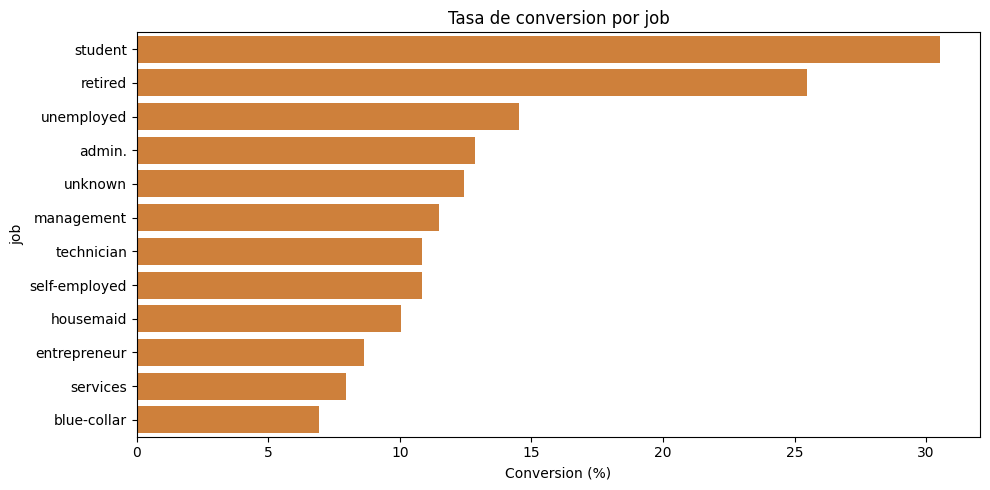

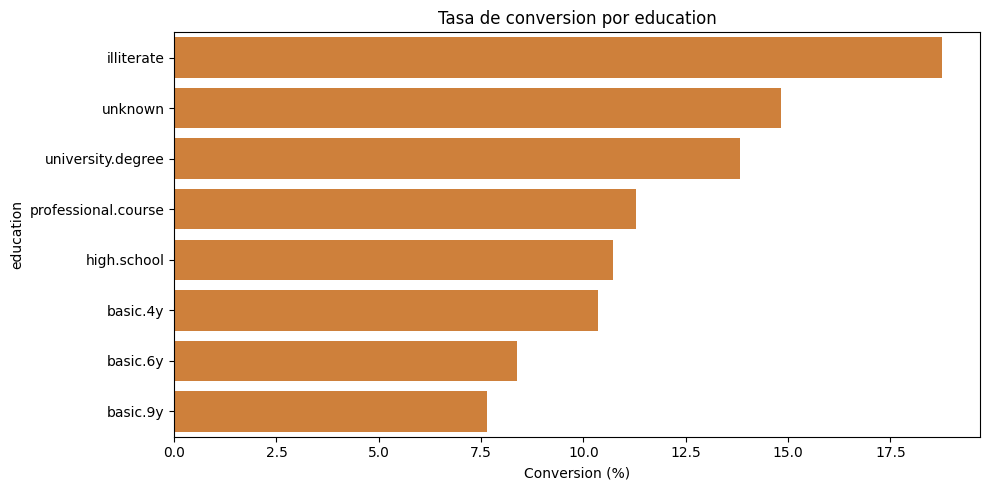

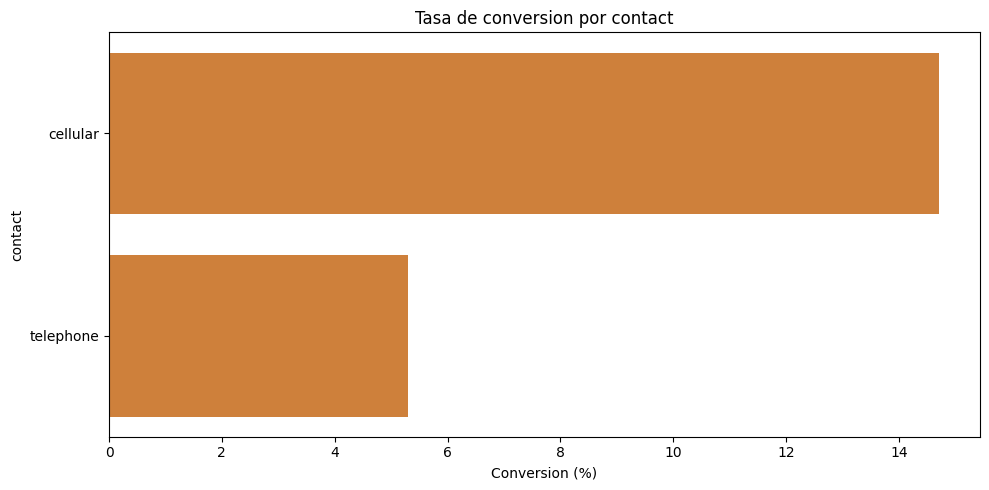

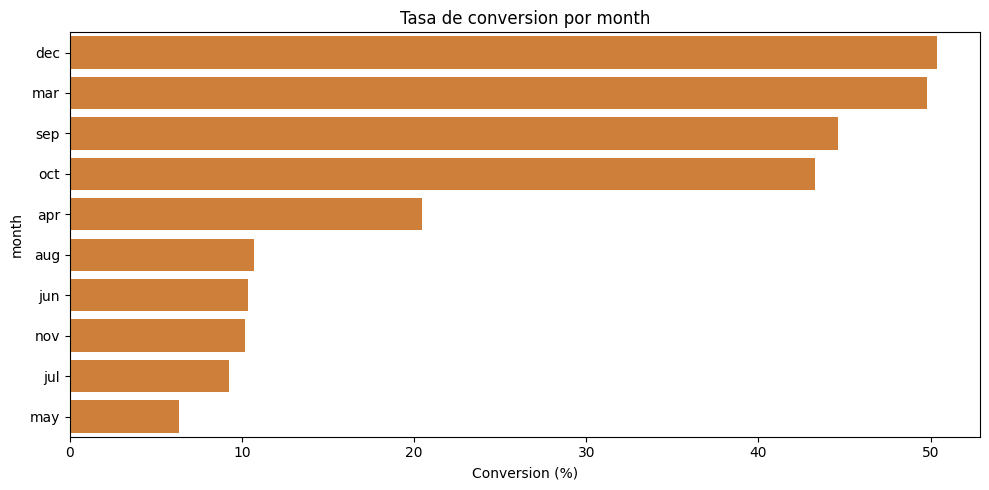

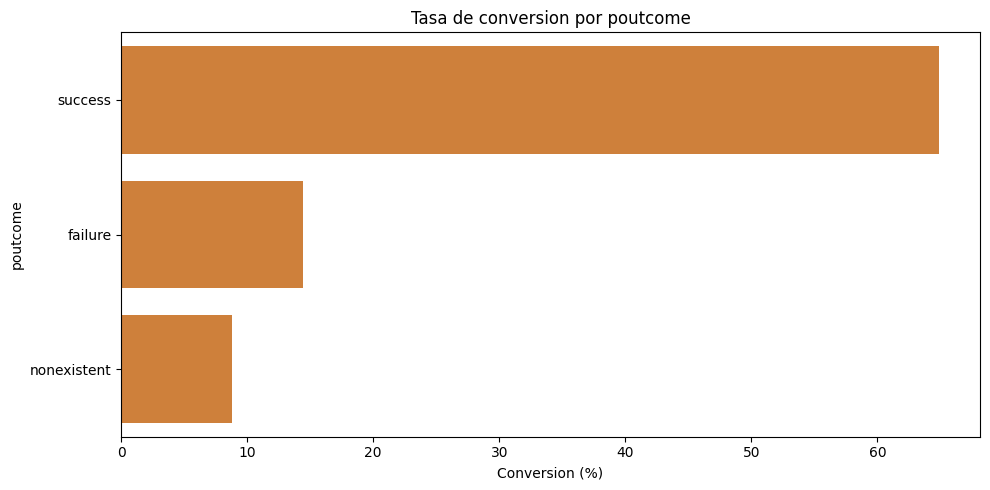

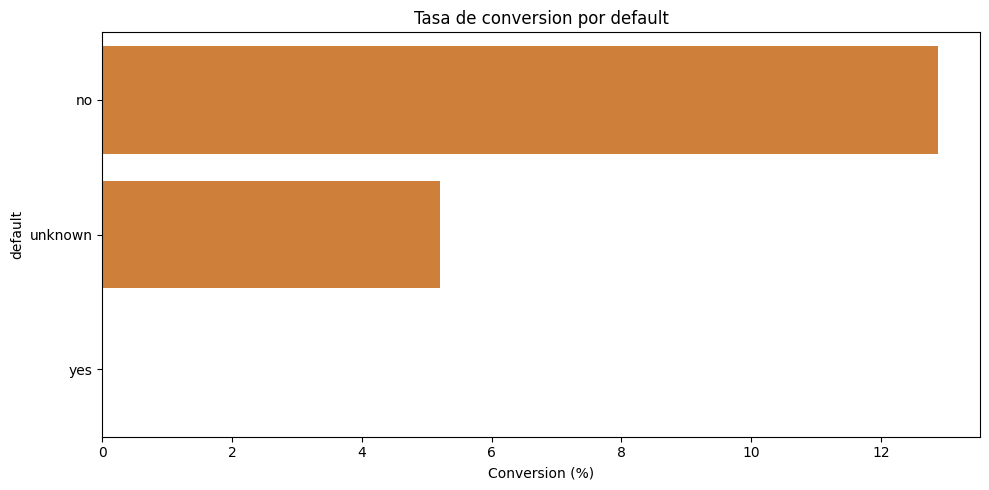

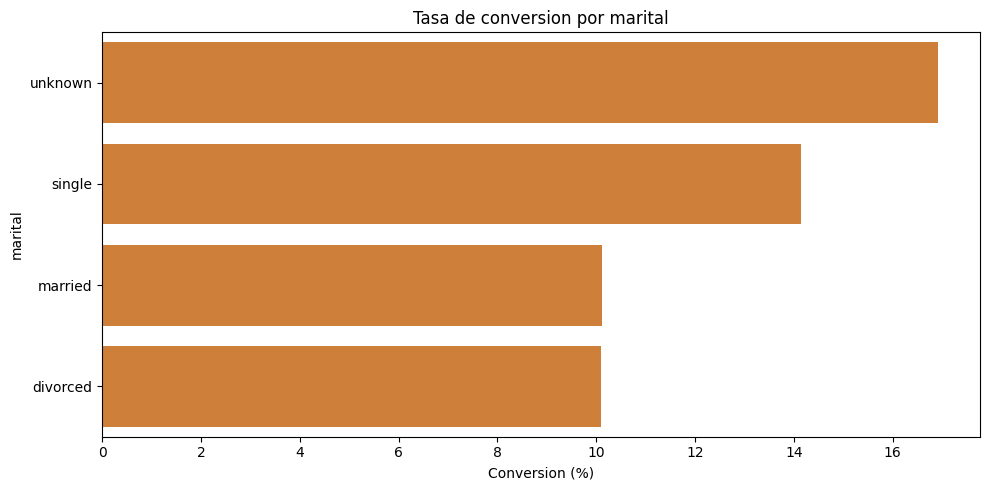

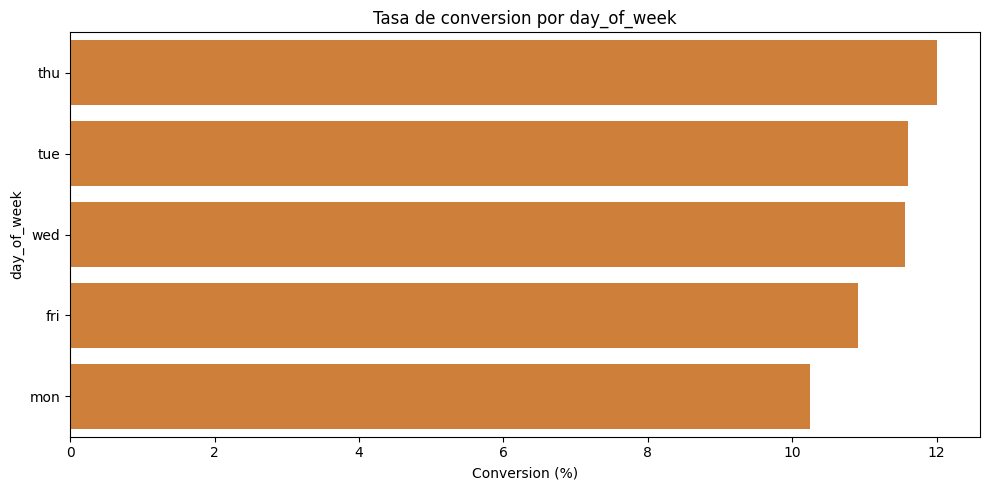

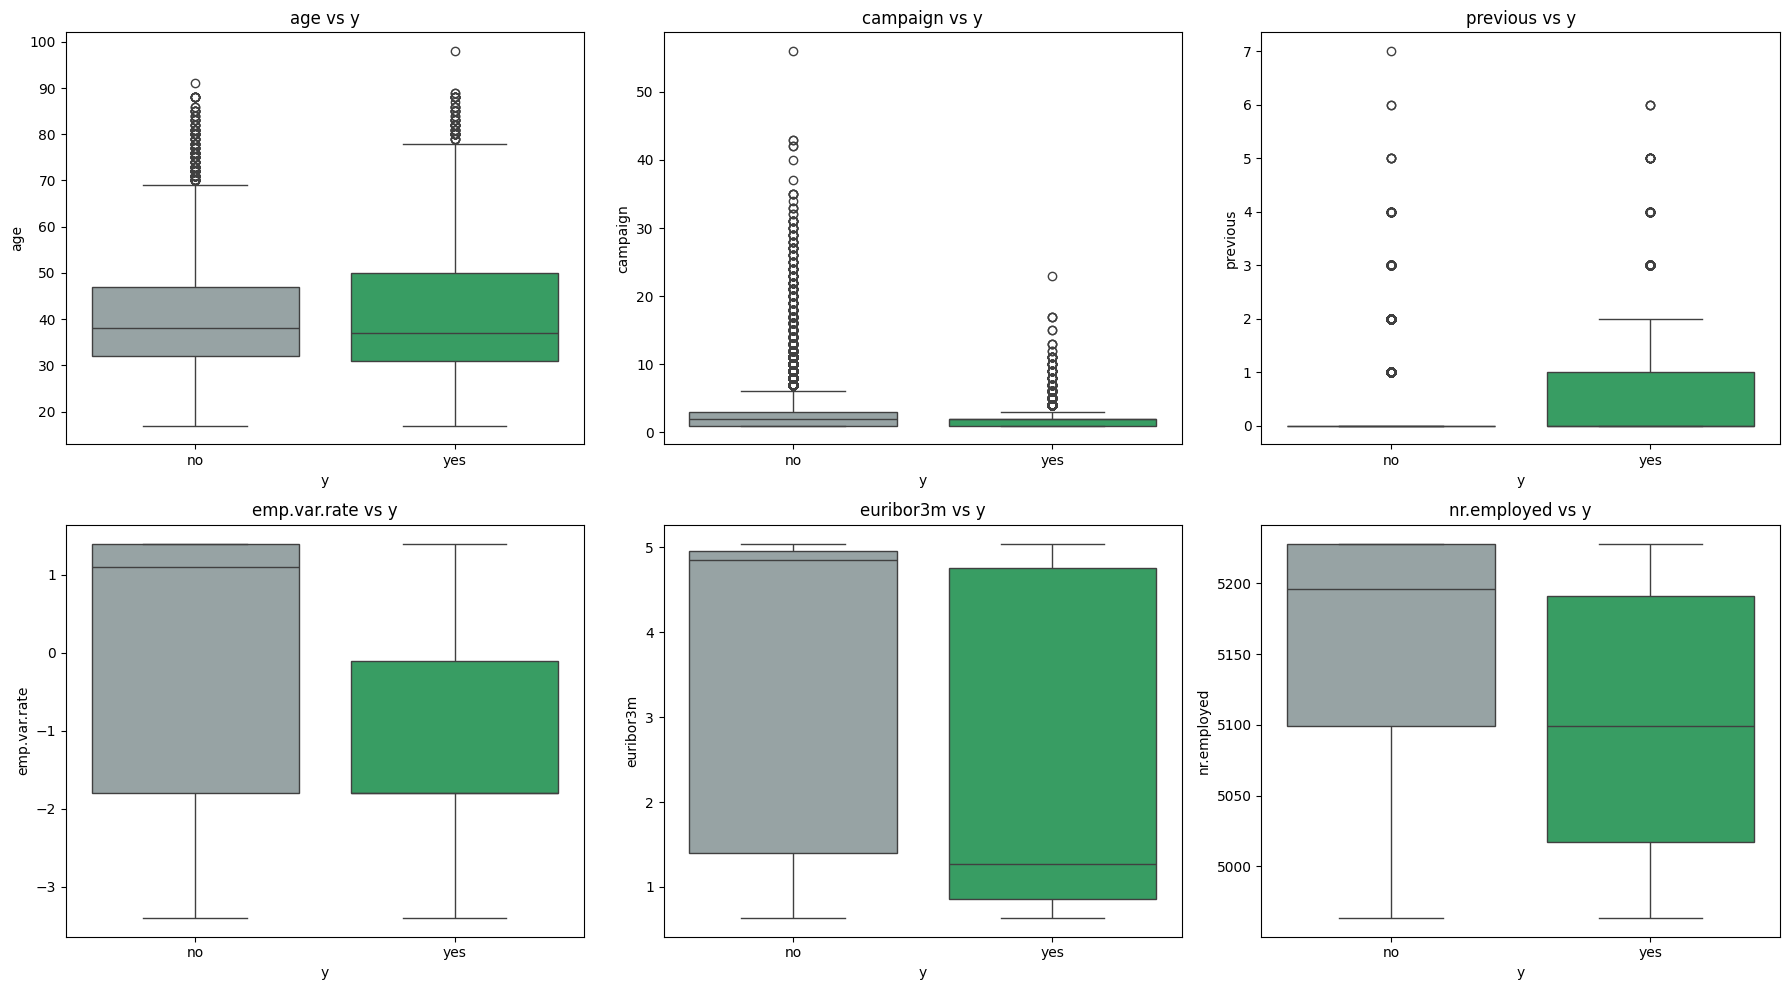

In [50]:
plot_df = train_df.copy()
plot_df['default'] = plot_df['default'].fillna('missing')
plot_df['education'] = plot_df['education'].fillna('missing')
plot_df['job'] = plot_df['job'].fillna('missing')
plot_df['marital'] = plot_df['marital'].fillna('missing')
plot_df['housing'] = plot_df['housing'].fillna('missing')
plot_df['loan'] = plot_df['loan'].fillna('missing')

def conversion_table(df, col):
    tmp = df.groupby(col)['y'].value_counts(normalize=True).unstack(fill_value=0)
    if 'yes' not in tmp.columns:
        tmp['yes'] = 0
    return tmp.assign(conversion_rate=tmp['yes'] * 100).sort_values('conversion_rate', ascending=False)

bivariate_cols = ['job', 'education', 'contact', 'month', 'poutcome', 'default', 'marital', 'day_of_week']
for col in bivariate_cols:
    table = conversion_table(plot_df, col).reset_index()
    display(table[[col, 'yes', 'no', 'conversion_rate']].head(10))
    plt.figure(figsize=(10, 5))
    sns.barplot(data=table, x='conversion_rate', y=col, color='#e67e22')
    plt.title(f'Tasa de conversion por {col}')
    plt.xlabel('Conversion (%)')
    plt.ylabel(col)
    plt.tight_layout()

numeric_bivariate_cols = ['age', 'campaign', 'previous', 'emp.var.rate', 'euribor3m', 'nr.employed']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, col in zip(axes, numeric_bivariate_cols):
    sns.boxplot(data=plot_df, x='y', y=col, hue='y', ax=ax, palette=['#95a5a6', '#27ae60'], dodge=False, legend=False)
    ax.set_title(f'{col} vs y')
plt.tight_layout()


## Preprocesamiento tecnico

Con el EDA ya ordenado, definimos el mapa de columnas para preparar imputacion, escalado y codificacion. Esta decision sigue hecha solo sobre `Train`.

In [51]:
numeric_cols = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

nominal_cols = [
    'job', 'marital', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]

ordinal_cols = ['education']
education_order = [
    'illiterate',
    'basic.4y',
    'basic.6y',
    'basic.9y',
    'high.school',
    'professional.course',
    'university.degree',
]

column_map = pd.DataFrame(
    [
        ('Numericas', ', '.join(numeric_cols)),
        ('Nominales', ', '.join(nominal_cols)),
        ('Ordinales', ', '.join(ordinal_cols)),
    ],
    columns=['Tipo', 'Columnas']
)
display(column_map)
print('Orden ordinal propuesto para education:')
print(' > '.join(education_order))


,Tipo,Columnas
0,Numericas,"age, campaign, pdays, previous, emp.var.rate, ..."
1,Nominales,"job, marital, default, housing, loan, contact,..."
2,Ordinales,education


Orden ordinal propuesto para education:
illiterate > basic.4y > basic.6y > basic.9y > high.school > professional.course > university.degree


### Escalamiento antes/después

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
feature,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
mean_before,40.014,2.561,962.052,0.175,0.08,93.576,-40.508,3.618,5166.9
std_before,10.404,2.752,187.951,0.499,1.571,0.579,4.628,1.736,72.435
mean_after,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0
std_after,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


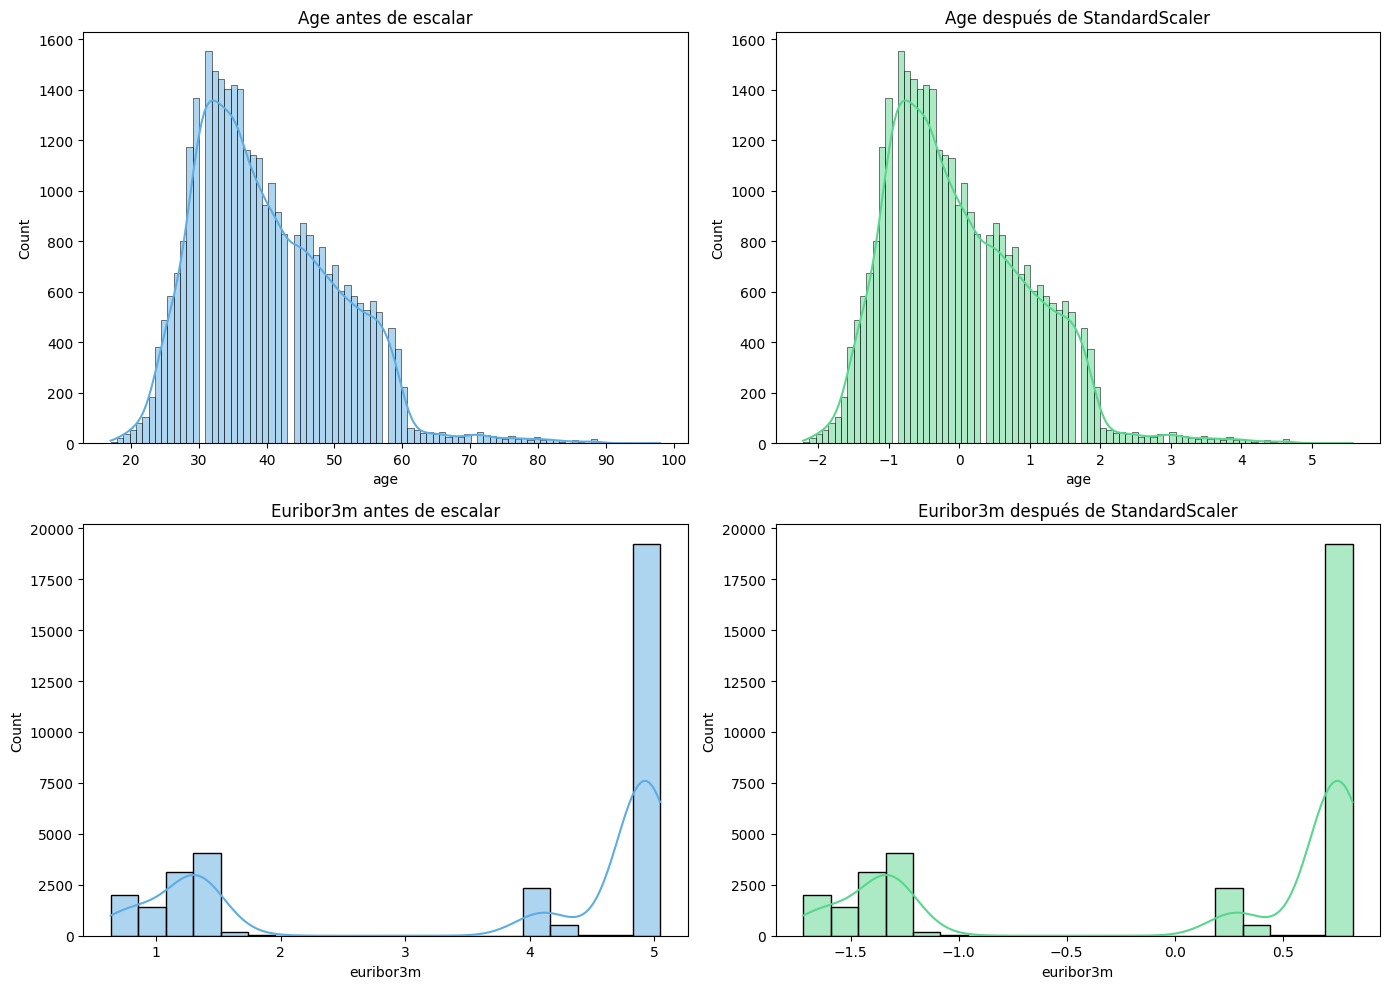

In [52]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

scaler = StandardScaler()
scaled_train = scaler.fit_transform(X_train_clean[numeric_cols])
scaled_train = pd.DataFrame(scaled_train, columns=numeric_cols)

compare_df = pd.DataFrame({
    'feature': numeric_cols,
    'mean_before': X_train_clean[numeric_cols].mean().round(3),
    'std_before': X_train_clean[numeric_cols].std().round(3),
    'mean_after': scaled_train.mean().round(3),
    'std_after': scaled_train.std().round(3),
})
display(compare_df.T)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(data=X_train_clean, x='age', kde=True, ax=axes[0,0], color='#5dade2')
axes[0,0].set_title('Age antes de escalar')
sns.histplot(data=scaled_train, x='age', kde=True, ax=axes[0,1], color='#58d68d')
axes[0,1].set_title('Age después de StandardScaler')
sns.histplot(data=X_train_clean, x='euribor3m', kde=True, ax=axes[1,0], color='#5dade2')
axes[1,0].set_title('Euribor3m antes de escalar')
sns.histplot(data=scaled_train, x='euribor3m', kde=True, ax=axes[1,1], color='#58d68d')
axes[1,1].set_title('Euribor3m después de StandardScaler')
plt.tight_layout()
plt.show()

## Pipeline reproducible

Con las columnas definidas, el siguiente paso es construir el `ColumnTransformer` y verificar que el ajuste ocurra solo con `Train`.

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

X_train_model = X_train_clean.copy().replace('', pd.NA)
X_test_model = pd.read_csv('../data/processed/X_test_clean.csv').replace('', pd.NA)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[education_order])),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('nom', nominal_transformer, nominal_cols),
        ('ord', ordinal_transformer, ordinal_cols),
    ],
    remainder='drop'
)

X_train_model = X_train_clean.replace('unknown', pd.NA)
X_test_model = X_test_model.replace('unknown', pd.NA)

preprocessor.fit(X_train_model)
X_train_transformed = preprocessor.transform(X_train_model)
X_test_transformed = preprocessor.transform(X_test_model)

print('X_train_model shape:', X_train_model.shape)
print('X_train_transformed shape:', X_train_transformed.shape)
print('X_test_model shape:', X_test_model.shape)
print('X_test_transformed shape:', X_test_transformed.shape)


X_train_model shape: (32950, 20)
X_train_transformed shape: (32950, 50)
X_test_model shape: (8238, 20)
X_test_transformed shape: (8238, 50)


In [54]:
import numpy as np

print('NaN en X_train_transformed:', np.isnan(np.asarray(X_train_transformed)).sum())
print('NaN en X_test_transformed:', np.isnan(np.asarray(X_test_transformed)).sum())
print('Consistencia dimensional:', X_train_transformed.shape[1] == X_test_transformed.shape[1])


NaN en X_train_transformed: 0
NaN en X_test_transformed: 0
Consistencia dimensional: True


### Codificación original vs transformada

In [55]:
nominal_cols = [
    'job', 'marital', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]

# Mostrar datos originales
display(train_df[['job', 'education']].head(10))

nominal_pipe = preprocessor.named_transformers_['nom']
onehot = nominal_pipe.named_steps['onehot']

X_nominal_train = nominal_pipe.named_steps['imputer'].transform(X_train_clean[nominal_cols])
X_ohe = onehot.transform(X_nominal_train)
ohe_cols = onehot.get_feature_names_out(nominal_cols)

ohe_df = pd.DataFrame(X_ohe, columns=ohe_cols).head(10)
display(ohe_df)

display(pd.concat([
    X_train_clean[['job']].reset_index(drop=True).head(10),
    ohe_df[[c for c in ohe_cols if c.startswith('job_')]].reset_index(drop=True)
], axis=1))

,job,education
0,blue-collar,basic.9y
1,entrepreneur,university.degree
2,retired,basic.4y
3,admin.,university.degree
4,retired,university.degree
5,admin.,university.degree
6,student,basic.9y
7,blue-collar,basic.4y
8,blue-collar,basic.4y
9,admin.,high.school


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
7,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


,job,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed
0,blue-collar,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,entrepreneur,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,retired,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,admin.,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,retired,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,admin.,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,student,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,blue-collar,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,blue-collar,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,admin.,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Ingenieria de caracteristicas

A partir de `Train` se crean variables adicionales que resumen edad, intensidad de contacto, contacto previo y contexto economico.

In [56]:
feature_df = train_df.copy()

feature_df['age_group'] = pd.cut(
    feature_df['age'],
    bins=[0, 29, 59, 120],
    labels=['joven', 'adulto', 'adulto_mayor'],
    include_lowest=True,
    right=True,
)

feature_df['contact_intensity'] = feature_df['campaign'] + feature_df['previous']
feature_df['had_previous_contact'] = (feature_df['previous'] > 0).astype(int)
feature_df['economic_risk_score'] = feature_df['euribor3m'] + feature_df['emp.var.rate']
campaign_threshold = int(feature_df['campaign'].quantile(0.75))
feature_df['frequently_contacted'] = (feature_df['campaign'] >= campaign_threshold).astype(int)

display(feature_df[['age', 'age_group', 'campaign', 'previous', 'contact_intensity', 'economic_risk_score', 'frequently_contacted']].head())
print('Umbral de campaign usado para contacto frecuente:', campaign_threshold)
print('Distribucion por grupo etario:')
display(feature_df['age_group'].value_counts(dropna=False).to_frame('count'))
print('Conversion por grupo etario:')
display(feature_df.groupby('age_group', observed=False)['y'].value_counts(normalize=True).unstack(fill_value=0))
print('Conversion por contacto previo:')
display(feature_df.groupby('had_previous_contact')['y'].value_counts(normalize=True).unstack(fill_value=0))
print('Conversion por contacto frecuente:')
display(feature_df.groupby('frequently_contacted')['y'].value_counts(normalize=True).unstack(fill_value=0))
print('Resumen de variables nuevas:')
display(feature_df[['contact_intensity', 'economic_risk_score']].describe().T)


,age,age_group,campaign,previous,contact_intensity,economic_risk_score,frequently_contacted
0,49,adulto,4,0,4,4.020,1
1,37,adulto,2,1,3,4.020,0
2,78,adulto_mayor,1,0,1,-0.830,0
3,36,adulto,2,0,2,5.957,0
4,59,adulto,2,0,2,-1.638,0


Umbral de campaign usado para contacto frecuente: 3
Distribucion por grupo etario:


,count
age_group,
adulto,27427
joven,4574
adulto_mayor,949


Conversion por grupo etario:


y,no,yes
age_group,,
joven,0.834937,0.165063
adulto,0.905896,0.094104
adulto_mayor,0.603793,0.396207


...

y,no,yes
had_previous_contact,,
0,0.911986,0.088014
1,0.732907,0.267093


Conversion por contacto frecuente:


y,no,yes
frequently_contacted,,
0,0.875874,0.124126
1,0.912355,0.087645


Resumen de variables nuevas:


,count,mean,std,min,25%,50%,75%,max
contact_intensity,32950.0,2.735326,2.758111,1.000,1.000,2.000,3.000,56.00
economic_risk_score,32950.0,3.698866,3.284117,-2.686,-0.435,5.957,6.361,6.37


In [57]:
feature_summary = pd.DataFrame({
    'feature': ['age_group', 'contact_intensity', 'had_previous_contact', 'economic_risk_score', 'frequently_contacted'],
    'purpose': [
        'Segmenta la edad en grupos interpretables.',
        'Resume el esfuerzo comercial acumulado.',
        'Detecta si existio contacto previo.',
        'Resume el contexto economico en un solo indicador.',
        'Marca clientes con mayor intensidad de seguimiento.'
    ]
})
display(feature_summary)


,feature,purpose
0,age_group,Segmenta la edad en grupos interpretables.
1,contact_intensity,Resume el esfuerzo comercial acumulado.
2,had_previous_contact,Detecta si existio contacto previo.
3,economic_risk_score,Resume el contexto economico en un solo indica...
4,frequently_contacted,Marca clientes con mayor intensidad de seguimi...


,age,age_group,campaign,previous,contact_intensity,economic_risk_score,frequently_contacted
0,49,Adulto,4,0,4,4.020,1
1,37,Adulto,2,1,3,4.020,0
2,78,Adulto Mayor,1,0,1,-0.830,0
3,36,Adulto,2,0,2,5.957,0
4,59,Adulto,2,0,2,-1.638,0


Umbral de campaign usado para contacto frecuente: 3


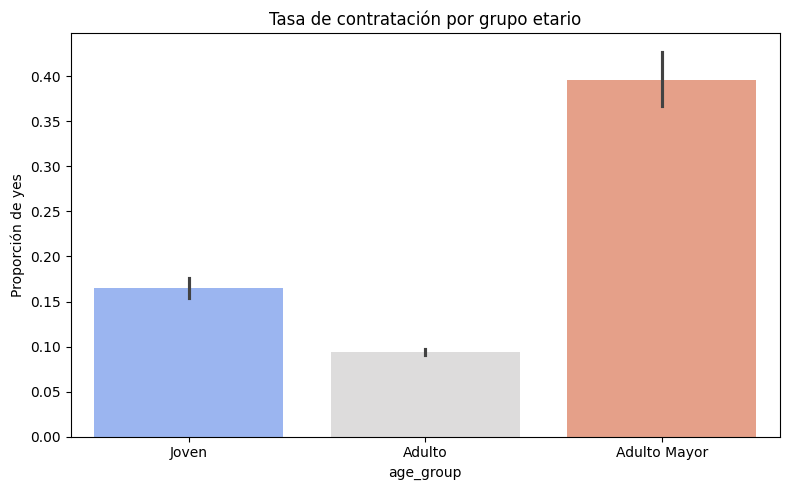

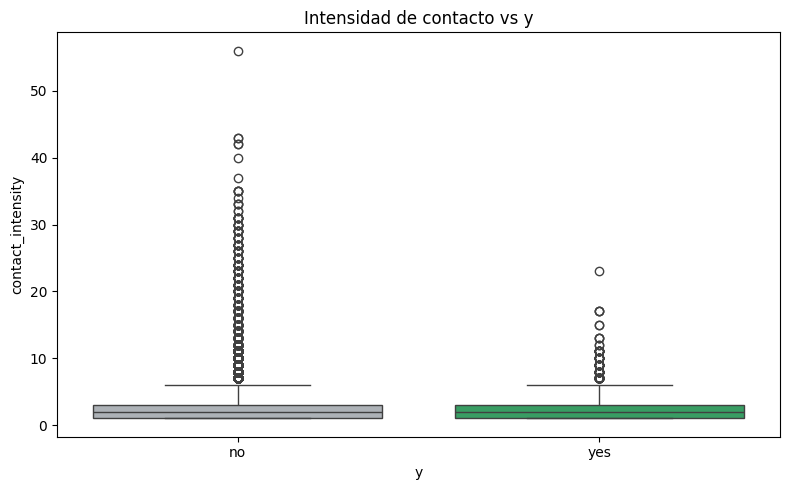

In [58]:
feature_df = train_df.copy()

feature_df['age_group'] = pd.cut(
    feature_df['age'],
    bins=[0, 29, 59, 120],
    labels=['Joven', 'Adulto', 'Adulto Mayor'],
    include_lowest=True
)
feature_df['contact_intensity'] = feature_df['campaign'] + feature_df['previous']
feature_df['had_previous_contact'] = (feature_df['previous'] > 0).astype(int)
feature_df['economic_risk_score'] = feature_df['euribor3m'] + feature_df['emp.var.rate']
campaign_threshold = int(feature_df['campaign'].quantile(0.75))
feature_df['frequently_contacted'] = (feature_df['campaign'] >= campaign_threshold).astype(int)

display(feature_df[['age', 'age_group', 'campaign', 'previous', 'contact_intensity', 'economic_risk_score', 'frequently_contacted']].head())
print('Umbral de campaign usado para contacto frecuente:', campaign_threshold)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=feature_df,
    x='age_group',
    y=(feature_df['y'] == 'yes').astype(int),
    estimator='mean',
    color='#4c72b0',
    ax=ax
)
ax.set_ylabel('Proporción de yes')
ax.set_title('Tasa de contratación por grupo etario')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=feature_df, x='y', y='contact_intensity', color='#95a5a6', ax=ax)
ax.set_title('Intensidad de contacto vs y')
plt.tight_layout()
plt.show()

## Validacion preliminar del aporte

Esta validacion compara la tasa de conversion del conjunto completo con la tasa obtenida al segmentar por las nuevas variables. Sirve para defender su utilidad antes de modelar.

In [59]:
overall_rate = (feature_df['y'] == 'yes').mean() * 100

validation_df = feature_df.copy()
validation_df['contact_intensity_band'] = pd.qcut(validation_df['contact_intensity'], q=4, duplicates='drop')
validation_df['economic_risk_band'] = pd.qcut(validation_df['economic_risk_score'], q=4, duplicates='drop')

validation_tables = {
    'age_group': validation_df.groupby('age_group', observed=False)['y'].value_counts(normalize=True).unstack(fill_value=0),
    'had_previous_contact': validation_df.groupby('had_previous_contact')['y'].value_counts(normalize=True).unstack(fill_value=0),
    'frequently_contacted': validation_df.groupby('frequently_contacted')['y'].value_counts(normalize=True).unstack(fill_value=0),
    'contact_intensity_band': validation_df.groupby('contact_intensity_band', observed=False)['y'].value_counts(normalize=True).unstack(fill_value=0),
    'economic_risk_band': validation_df.groupby('economic_risk_band', observed=False)['y'].value_counts(normalize=True).unstack(fill_value=0),
}

summary_rows = []
for feature_name, table in validation_tables.items():
    if 'yes' not in table.columns:
        table['yes'] = 0
    yes_rates = table['yes'] * 100
    summary_rows.append({
        'feature': feature_name,
        'max_conversion': yes_rates.max(),
        'min_conversion': yes_rates.min(),
        'gap_vs_overall_max': yes_rates.max() - overall_rate,
        'gap_vs_overall_min': yes_rates.min() - overall_rate,
    })

summary_validation = pd.DataFrame(summary_rows).sort_values('gap_vs_overall_max', ascending=False)
display(summary_validation)
print(f'Tasa base global de conversion: {overall_rate:.2f}%')
print('Lectura rapida: valores positivos altos en gap_vs_overall_max indican segmentos con capacidad de concentrar conversion.')


,feature,max_conversion,min_conversion,gap_vs_overall_max,gap_vs_overall_min
0,age_group,39.620653,9.410435,28.355099,-1.855119
1,had_previous_contact,26.709307,8.801380,15.443754,-2.464174
4,economic_risk_band,24.277526,4.899987,13.011972,-6.365567
3,contact_intensity_band,13.779148,10.664495,2.513594,-0.601059
2,frequently_contacted,12.412572,8.764479,1.147018,-2.501075


Tasa base global de conversion: 11.27%
Lectura rapida: valores positivos altos en gap_vs_overall_max indican segmentos con capacidad de concentrar conversion.


## Cierre del entregable

Esta seccion deja explicitado que graficos se conservan, que conclusiones tecnicas sostienen el flujo y que documentos sirven como referencia del trabajo.

### Graficos finales seleccionados

- Histogramas de variables numericas en `Train`.
- Countplots de variables categoricas relevantes.
- Barras de tasa de conversion por categoria para `job`, `education`, `contact`, `month`, `poutcome`, `default`, `marital` y `day_of_week`.
- Boxplots de `age`, `campaign`, `previous`, `emp.var.rate`, `euribor3m` y `nr.employed` contra `y`.
- Resumen de variables de ingenieria de caracteristicas y su lectura de negocio.

Estos graficos se priorizan porque explican tanto la calidad del dato como la separacion entre clases y la interpretacion de negocio.

### Conclusiones tecnicas

- El split estratificado debio ocurrir antes de cualquier transformacion aprendida para evitar `data leakage`.
- `duration` quedo excluida del flujo analitico por su alto riesgo metodologico.
- Los valores `unknown` se trataron como faltantes y no como categorias verdaderas.
- El pipeline separa imputacion, escalado y codificacion con ajuste exclusivo sobre `Train`.
- `contact`, `poutcome`, `month`, `campaign`, `previous` y `euribor3m` muestran capacidad real de separacion entre `yes` y `no`.
- La ingenieria de caracteristicas agrega una capa de interpretacion, pero su aporte final debe validarse con modelado posterior.

El resultado es un flujo reproducible y trazable, listo para continuar con modelado sin mezclar conjuntos ni recalcular estadisticas sobre `Test`.

### Referencias

- `docs/md-fuente/AUDITORIA_Y_ETAPAS_PROYECTO.md`
- `docs/md-fuente/Acta de proyecto preprocesamiento.md`
- `docs/md-fuente/EVALUACIÓN PARCIAL 4_ESTUDIANTE.md`
- `docs/md-fuente/MARCO_TEORICO_Y_EXPLICATIVO.md`
- `data/raw/bank-additional-full.csv`

Estas fuentes sustentan la metodologia, el orden de trabajo y el criterio anti-leakage aplicado en el proyecto.